# 1. Imports

In [1]:
import sys

sys.path.append("..")

from src.utils.evaluation import evaluate_model

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

from imblearn.over_sampling import SMOTE

print("Libraries Loaded")

Libraries Loaded


In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 2. Load Dataset

In [4]:
DATA_PATH = "../data/raw/boi_transactions.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

(9082, 3925)


# 3. Data Cleaning

In [5]:
df.drop(columns=["Unnamed: 0"], inplace=True)

print(df.shape)

(9082, 3924)


# 4. Feature Selection

In [6]:
target = "F3924"

X = df.drop(columns=[target])

y = df[target]

print(X.shape)
print(y.shape)

(9082, 3923)
(9082,)


In [7]:
# Remove leakage feature
X = X.drop(columns=["F2230"])

# 5. Missing Value Handling

In [8]:
empty_columns = X.columns[X.isnull().all()]

print("Empty Columns:", len(empty_columns))

X = X.drop(columns=empty_columns)

print(X.shape)

Empty Columns: 63
(9082, 3859)


In [9]:
constant_columns = [
    col
    for col in X.columns
    if X[col].nunique(dropna=False) == 1
]

print(len(constant_columns))

X = X.drop(columns=constant_columns)

print(X.shape)

1
(9082, 3858)


In [10]:
missing_percentage = X.isnull().mean() * 100

high_missing = missing_percentage[
    missing_percentage > 80
].index

print("Columns Removed:", len(high_missing))

X = X.drop(columns=high_missing)

print(X.shape)

Columns Removed: 845
(9082, 3013)


In [11]:
leakage_features = ["F3912"]

X = X.drop(columns=leakage_features)

print(X.shape)

(9082, 3012)


In [12]:
numerical_columns = X.select_dtypes(include=["number"]).columns

categorical_columns = X.select_dtypes(include=["object"]).columns

print("Numerical:", len(numerical_columns))
print("Categorical:", len(categorical_columns))

Numerical: 3005
Categorical: 7


In [13]:
from sklearn.impute import SimpleImputer

# Numerical features
num_imputer = SimpleImputer(strategy="median")

# Categorical features
cat_imputer = SimpleImputer(strategy="most_frequent")

X[numerical_columns] = num_imputer.fit_transform(X[numerical_columns])

X[categorical_columns] = cat_imputer.fit_transform(X[categorical_columns])

print("Remaining Missing Values :", X.isnull().sum().sum())

Remaining Missing Values : 0


In [14]:
missing_after = X.isnull().sum()

missing_after[missing_after > 0]

Series([], dtype: int64)

# 6. Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training :", X_train.shape)
print("Testing  :", X_test.shape)

print("\nTarget Distribution")
print(y_train.value_counts())
print(y_test.value_counts())

Training : (7265, 3012)
Testing  : (1817, 3012)

Target Distribution
F3924
0    7200
1      65
Name: count, dtype: int64
F3924
0    1801
1      16
Name: count, dtype: int64


# 7. Preprocessing Pipeline

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Detect columns from TRAIN ONLY
numerical_columns = X_train.select_dtypes(include=["number"]).columns
categorical_columns = X_train.select_dtypes(include=["object"]).columns

print("Numerical :", len(numerical_columns))
print("Categorical :", len(categorical_columns))


# Numerical preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_columns),
    ("cat", categorical_transformer, categorical_columns)
])

print("Preprocessor Ready!")

Numerical : 3005
Categorical : 7
Preprocessor Ready!


In [17]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(7265, 6879)
(1817, 6879)


# 8. Handle Class Imbalance (SMOTE)

In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

print("\nShape :", X_train_smote.shape)

Before SMOTE
F3924
0    7200
1      65
Name: count, dtype: int64

After SMOTE
F3924
0    7200
1    7200
Name: count, dtype: int64

Shape : (14400, 6879)


In [19]:
print("="*50)
print("Pipeline Summary")
print("="*50)

print("Original Dataset :", df.shape)
print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)
print("After Encoding :", X_train_processed.shape)
print("After SMOTE :", X_train_smote.shape)

Pipeline Summary
Original Dataset : (9082, 3924)
Training Set : (7265, 3012)
Testing Set : (1817, 3012)
After Encoding : (7265, 6879)
After SMOTE : (14400, 6879)


In [22]:
# Store metrics of all models
results = []

# 9. Logistic Regression (Baseline)

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
lr = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

lr.fit(X_train_smote, y_train_smote)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


Logistic Regression
Accuracy : 0.8701
Precision: 0.0600
Recall   : 0.9375
F1 Score : 0.1128
ROC AUC  : 0.8936
PR AUC   : 0.0433

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.87      0.93      1801
           1       0.06      0.94      0.11        16

    accuracy                           0.87      1817
   macro avg       0.53      0.90      0.52      1817
weighted avg       0.99      0.87      0.92      1817



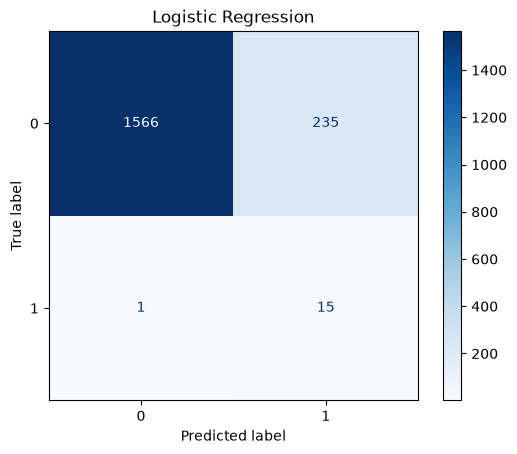

In [25]:
lr_metrics = evaluate_model(
    lr,
    X_test_processed,
    y_test,
    "Logistic Regression"
)

lr_metrics["Model"] = "Logistic Regression"

results.append(lr_metrics)

# 10. Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train_smote, y_train_smote)

print("Random Forest trained successfully!")

Random Forest trained successfully!


Random Forest
Accuracy : 0.9967
Precision: 1.0000
Recall   : 0.6250
F1 Score : 0.7692
ROC AUC  : 0.9965
PR AUC   : 0.8785

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       1.00      0.62      0.77        16

    accuracy                           1.00      1817
   macro avg       1.00      0.81      0.88      1817
weighted avg       1.00      1.00      1.00      1817



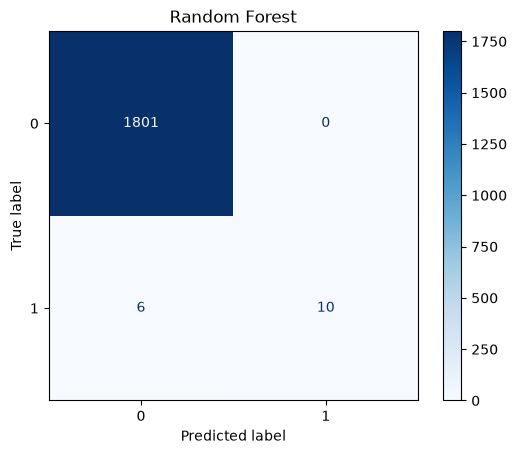

In [28]:
rf_metrics = evaluate_model(
    rf,
    X_test_processed,
    y_test,
    "Random Forest"
)

rf_metrics["Model"] = "Random Forest"

results.append(rf_metrics)

# 11. XGBoost

In [29]:
from xgboost import XGBClassifier

In [30]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

print("XGBoost trained successfully!")

XGBoost trained successfully!


XGBoost
Accuracy : 0.9983
Precision: 1.0000
Recall   : 0.8125
F1 Score : 0.8966
ROC AUC  : 0.9990
PR AUC   : 0.9534

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       1.00      0.81      0.90        16

    accuracy                           1.00      1817
   macro avg       1.00      0.91      0.95      1817
weighted avg       1.00      1.00      1.00      1817



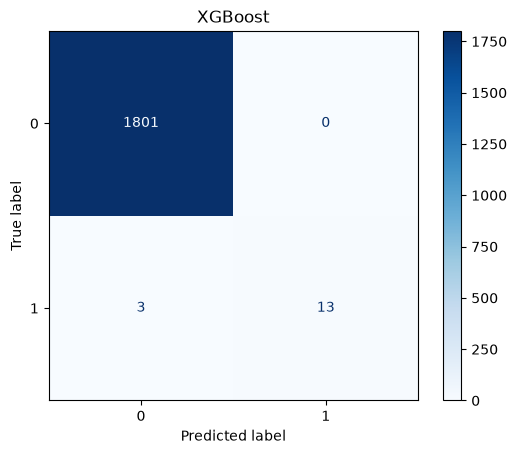

In [31]:
xgb_metrics = evaluate_model(
    xgb,
    X_test_processed,
    y_test,
    "XGBoost"
)

xgb_metrics["Model"] = "XGBoost"

results.append(xgb_metrics)

In [32]:
results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ]
]

results_df.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,XGBoost,0.998349,1.00,0.8125,0.896552,0.998994,0.953403
1,Random Forest,0.996698,1.00,0.6250,0.769231,0.996460,0.878452
0,Logistic Regression,0.870116,0.06,0.9375,0.112782,0.893566,0.043325


In [33]:
results_df.to_csv(
    "../reports/model_results.csv",
    index=False
)

print("Model comparison saved!")

Model comparison saved!


In [34]:
preprocessor.get_feature_names_out()

array(['num__F1', 'num__F4', 'num__F13', ..., 'cat__F3892_O',
       'cat__F3893_CORPORATE', 'cat__F3893_RETAIL'],
      shape=(6879,), dtype=object)

In [35]:
feature_names = preprocessor.get_feature_names_out()

In [36]:
len(feature_names)

6879

In [37]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb.feature_importances_
})

In [38]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
2991,num__F3908,0.049677
2747,num__F3645,0.049537
2981,num__F3898,0.045982
2995,num__F3914,0.038704
6878,cat__F3893_RETAIL,0.022940
690,num__F996,0.022831
1338,num__F1644,0.021619
1014,num__F1320,0.019047
905,num__F1211,0.018780
2744,num__F3642,0.018710


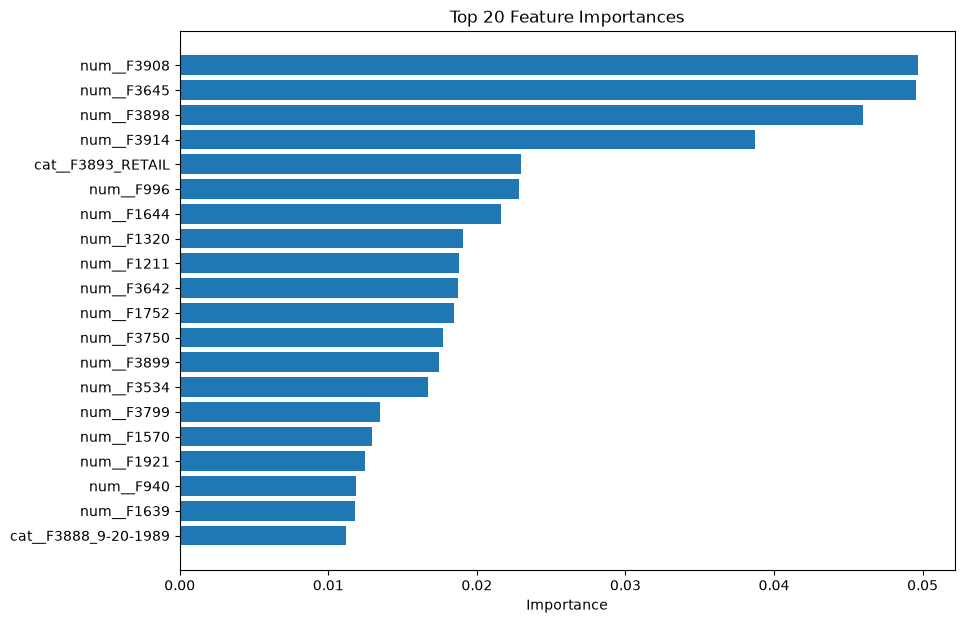

In [39]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10,7))

plt.barh(
    top20["Feature"][::-1],
    top20["Importance"][::-1]
)

plt.title("Top 20 Feature Importances")

plt.xlabel("Importance")

plt.show()

In [40]:
importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

print("Feature importance saved!")

Feature importance saved!


In [41]:
import joblib

In [42]:
joblib.dump(
    lr,
    "../models/logistic_regression.pkl"
)

['../models/logistic_regression.pkl']

In [43]:
joblib.dump(
    rf,
    "../models/random_forest.pkl"
)

['../models/random_forest.pkl']

In [44]:
joblib.dump(
    xgb,
    "../models/xgboost.pkl"
)

['../models/xgboost.pkl']

In [45]:
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

['../models/preprocessor.pkl']

In [46]:
import joblib

joblib.dump(X_train_smote, "../models/X_train_smote.pkl")
joblib.dump(y_train_smote, "../models/y_train_smote.pkl")

joblib.dump(X_test_processed, "../models/X_test_processed.pkl")
joblib.dump(y_test, "../models/y_test.pkl")

print("Processed datasets saved.")

Processed datasets saved.
